# Quantum Optics - Homework 5 - Quantum limits to displacement sensing

## Jan Chelmecki

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In a quantum optical measurement, all beams will be subject to a noise smaller than some nonzero minimal value. For coherent states, the noise is independent of the amplitude, and so it is of interest to increase the latter to attain a better signal to noise ratio. However, by doing so, we also increase our impact on the system (radiation pressure, for example) and for very strong signals, the dynamics of the system will be dominated by this undesirable effect of the apparatus, making the inherent dynamics much smaller by ampitude and hence, again, difficult to measure. The compromise above leads to the concept of the Standard Quantum Limit, which might be defied for example by using squeezed light or, as in the paper, by real-time control of the system basing on measurement outcomes.

I do admit I have a problem to analyze the data. My Lorentzian fits do not match those for data series 1 and 2 and for series 3 and 4, scipy encounters a problem, which I see might happen when the class of the fitting functions does not describe the data well. I am fitting
$$
S_{yy} = \frac{S_0}{1+(f/f_0)^2}
$$
since the paper mention Lorentzian peaks but I fear I might be working with a wrong class of functions.

Let's unpack the data and plot it.

In [2]:
data = pd.read_csv("HW5_data.csv")
data

,freq_0_data,Syy_0_data,freq_1_data,Syy_1_data,freq_2_data,Syy_2_data,freq_3_data,Syy_3_data,freq_4_data,Syy_4_data,...,freq_1_fit,Syy_1_fit,freq_2_fit,Syy_2_fit,freq_3_fit,Syy_3_fit,freq_4_fit,Syy_4_fit,freq_5_fit,Syy_5_fit
0,-9.995726,2.190000e-34,-9.990888,3.610000e-34,-9.986191,5.530000e-34,-9.994054,1.540000e-33,-9.986738,6.060000e-33,...,-9.997771,3.290000e-34,-9.997713,6.280000e-34,-9.997656,1.510000e-33,-9.997780,5.750000e-33,-9.99771,1.580000e-32
1,-9.935726,2.050000e-34,-9.930888,3.150000e-34,-9.956191,6.130000e-34,-9.964054,1.630000e-33,-9.956738,6.460000e-33,...,-9.992971,3.290000e-34,-9.992913,6.280000e-34,-9.992856,1.510000e-33,-9.992980,5.750000e-33,-9.99291,1.580000e-32
2,-9.875726,2.130000e-34,-9.870888,2.860000e-34,-9.926191,5.950000e-34,-9.934054,1.500000e-33,-9.926738,7.610000e-33,...,-9.988171,3.290000e-34,-9.988113,6.280000e-34,-9.988056,1.510000e-33,-9.988180,5.750000e-33,-9.98811,1.580000e-32
3,-9.815726,2.230000e-34,-9.810888,3.280000e-34,-9.896191,5.650000e-34,-9.904054,1.470000e-33,-9.896738,5.800000e-33,...,-9.983371,3.290000e-34,-9.983313,6.280000e-34,-9.983256,1.510000e-33,-9.983380,5.750000e-33,-9.98331,1.580000e-32
4,-9.755726,2.190000e-34,-9.750888,3.320000e-34,-9.866191,5.620000e-34,-9.874054,1.390000e-33,-9.866738,5.170000e-33,...,-9.978571,3.290000e-34,-9.978513,6.280000e-34,-9.978456,1.510000e-33,-9.978580,5.750000e-33,-9.97851,1.580000e-32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.975229,3.290000e-34,9.975287,6.280000e-34,9.975344,1.510000e-33,9.975219,5.750000e-33,9.97529,1.580000e-32
4162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.980029,3.290000e-34,9.980087,6.280000e-34,9.980144,1.510000e-33,9.980019,5.750000e-33,9.98009,1.580000e-32
4163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.984829,3.290000e-34,9.984887,6.280000e-34,9.984944,1.510000e-33,9.984820,5.750000e-33,9.98489,1.580000e-32
4164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.989629,3.290000e-34,9.989687,6.280000e-34,9.989744,1.510000e-33,9.989620,5.750000e-33,9.98969,1.580000e-32


Text(0, 0.5, '$ S_{yy}(\\Omega) \\;\\; (m^2 Hz^{-1})$')

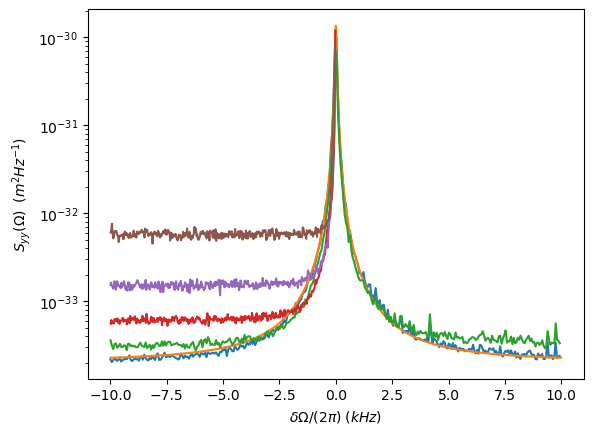

In [3]:
plt.semilogy(data["freq_0_data"], data["Syy_0_data"])
plt.semilogy(data["freq_0_fit"], data["Syy_0_fit"])
plt.semilogy(data["freq_1_data"], data["Syy_1_data"])
plt.semilogy(data["freq_2_data"], data["Syy_2_data"])
plt.semilogy(data["freq_3_data"], data["Syy_3_data"])
plt.semilogy(data["freq_4_data"], data["Syy_4_data"])
plt.xlabel("$\delta \Omega /(2\pi) \; (kHz) $")
plt.ylabel("$ S_{yy}(\Omega) \;\; (m^2 Hz^{-1})$")

Rather annoyingly, for some curves, half of the data is missing. We will remeady this but assuming the functions are symmetric around 0 and by reflecting the left branch for the curves that miss values. Also, due to the choice of the SI units, the values of $S_{yy}$ are of order of $10^{-30}$, which is potentially bad for numerics. I will alleviate this issue by rescaling $S_{yy}$ in my code.

In [4]:
data.columns

Index(['freq_0_data', 'Syy_0_data', 'freq_1_data', 'Syy_1_data', 'freq_2_data',
       'Syy_2_data', 'freq_3_data', 'Syy_3_data', 'freq_4_data', 'Syy_4_data',
       'freq_5_data', 'Syy_5_data', 'freq_0_fit', 'Syy_0_fit', 'freq_1_fit',
       'Syy_1_fit', 'freq_2_fit', 'Syy_2_fit', 'freq_3_fit', 'Syy_3_fit',
       'freq_4_fit', 'Syy_4_fit', 'freq_5_fit', 'Syy_5_fit'],
      dtype='object')

Function coefficients:
[1.03421895e+00 4.12294724e-02 2.26828106e-04]
Covariance of coefficients:
[[ 7.04516796e-05 -3.24069582e-06  1.25703404e-07]
 [-3.24069582e-06  1.68336278e-07 -9.16684507e-09]
 [ 1.25703404e-07 -9.16684507e-09  2.30340740e-08]]


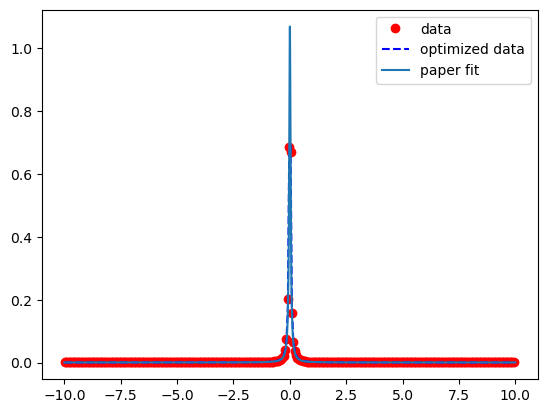

In [38]:
from scipy.optimize import curve_fit
x = data["freq_1_data"].dropna()
y = data["Syy_1_data"].dropna()*1E30

if np.max(x)<0:
    x = np.concatenate((x,-x[::-1]))
    y = np.concatenate((y,y[::-1]))
    
# Lorentz function model
def lorentz(x, a, b,c):
    return a /(1+ (x/b)**2)+c

# Fit the model to the data
param, param_cov = curve_fit(lorentz, x, y)

print("Function coefficients:")
print(param)
print("Covariance of coefficients:")
print(param_cov)

# Generate fitted values using the optimized parameters
ans = param[0]/(1+ (x/param[1])**2) + param[2]

# Plot original and fitted data
plt.plot(x, y, 'o', color='red', label="data")
plt.plot(x, ans, '--', color='blue', label="optimized data")
plt.plot(data["freq_1_fit"].dropna(), data["Syy_1_fit"].dropna()*1E30, label="paper fit")
plt.legend()
plt.show()

In [39]:
from scipy.optimize import curve_fit
x = data["freq_4_data"].dropna()
y = data["Syy_4_data"].dropna()*1E30

if np.max(x)<0:
    x = np.concatenate((x,-x[::-1]))
    y = np.concatenate((y,y[::-1]))
    
# Lorentz function model
def lorentz(x, a, b,c):
    return a /(1+ (x/b)**2)+c

# Fit the model to the data
param, param_cov = curve_fit(lorentz, x, y)

print("Function coefficients:")
print(param)
print("Covariance of coefficients:")
print(param_cov)

# Generate fitted values using the optimized parameters
ans = param[0]/(1+ (x/param[1])**2) + param[2]

# Plot original and fitted data
plt.plot(x, y, 'o', color='red', label="data")
plt.plot(x, ans, '--', color='blue', label="optimized data")
plt.plot(data["freq_4_fit"].dropna(), data["Syy_4_fit"].dropna()*1E30, label="paper fit")
plt.legend()
plt.show()

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.